<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

'wget' is not recognized as an internal or external command,
operable program or batch file.


#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas


[notice] A new release of pip is available: 25.1 -> 25.2
[notice] To update, run: C:\Users\21650\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [3]:
!pip install matplotlib


[notice] A new release of pip is available: 25.1 -> 25.2
[notice] To update, run: C:\Users\21650\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [84]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


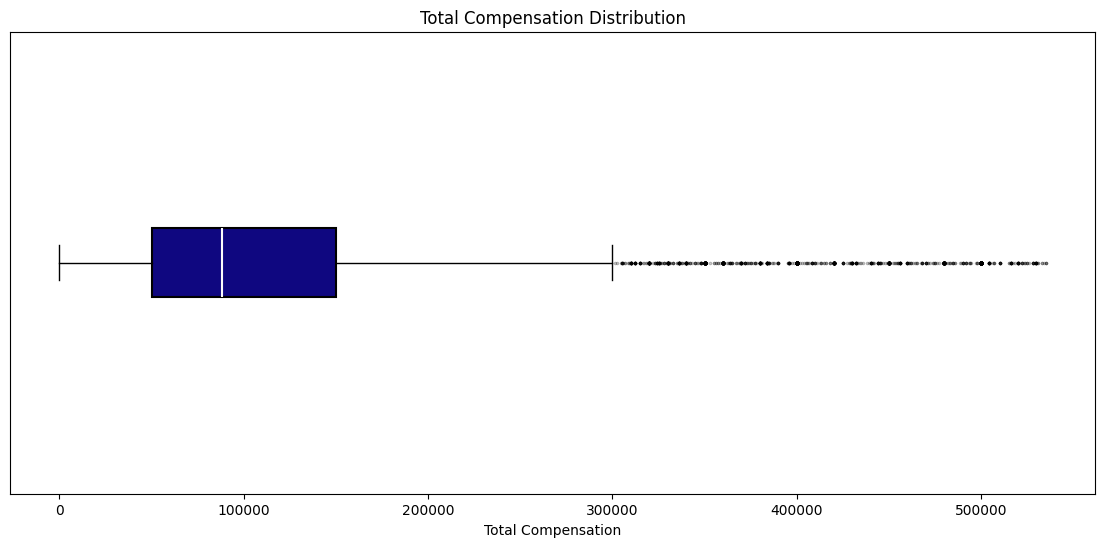

In [86]:
# your code goes here
QUERY="SELECT * FROM main"
df=pd.read_sql_query(QUERY,conn)
df.head()

plt.figure(figsize=(14,6))
Q1=df["CompTotal"].quantile(.25)
Q3=df["CompTotal"].quantile(.75)
IQR=Q3-Q1
lb=Q1-1.5*IQR
ub=Q3+1.5*IQR
df_cleaned=df[(lb<=df["CompTotal"])&(df["CompTotal"]<=ub)]
bxplot=plt.boxplot(df_cleaned["CompTotal"].dropna(),orientation='horizontal',patch_artist=True)

for box in bxplot["boxes"]:
    box.set(facecolor="#0f0780", edgecolor="black", linewidth=1.5)
for box in bxplot["medians"]:
    box.set(color="#fbfbfb", linewidth=1.5)
for flier in bxplot["fliers"]:
    flier.set(marker='.', color='pink', alpha=0.3,markersize=3)
plt.xlabel("Total Compensation")
plt.title("Total Compensation Distribution")
plt.yticks([])
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


C:\Users\21650\AppData\Local\Temp\ipykernel_6100\2567905257.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Age_converted"]=df["Age"].replace(age_map)


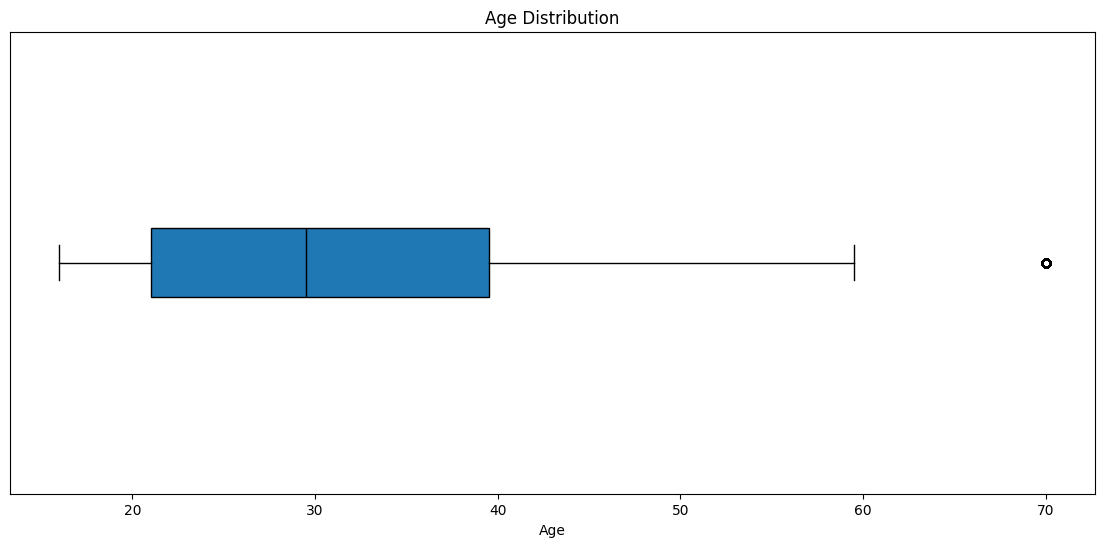

In [9]:
# your code goes here
import numpy as np
age_map={'Under 18 years old':16,
         '18-24 years old':21,
         '25-34 years old':29.5,
         '35-44 years old':39.5,
         '45-54 years old':49.5,
         '55-64 years old':59.5,
         '65 years or older':70,
         'Prefer not to say':np.nan
         }
df["Age_converted"]=df["Age"].replace(age_map)

plt.figure(figsize=(14,6))
bxplot=plt.boxplot(df["Age_converted"].dropna(),orientation='horizontal',patch_artist=True)
plt.yticks([])
plt.xlabel("Age")
plt.title("Age Distribution")
bxplot["medians"][0].set(color='black')
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


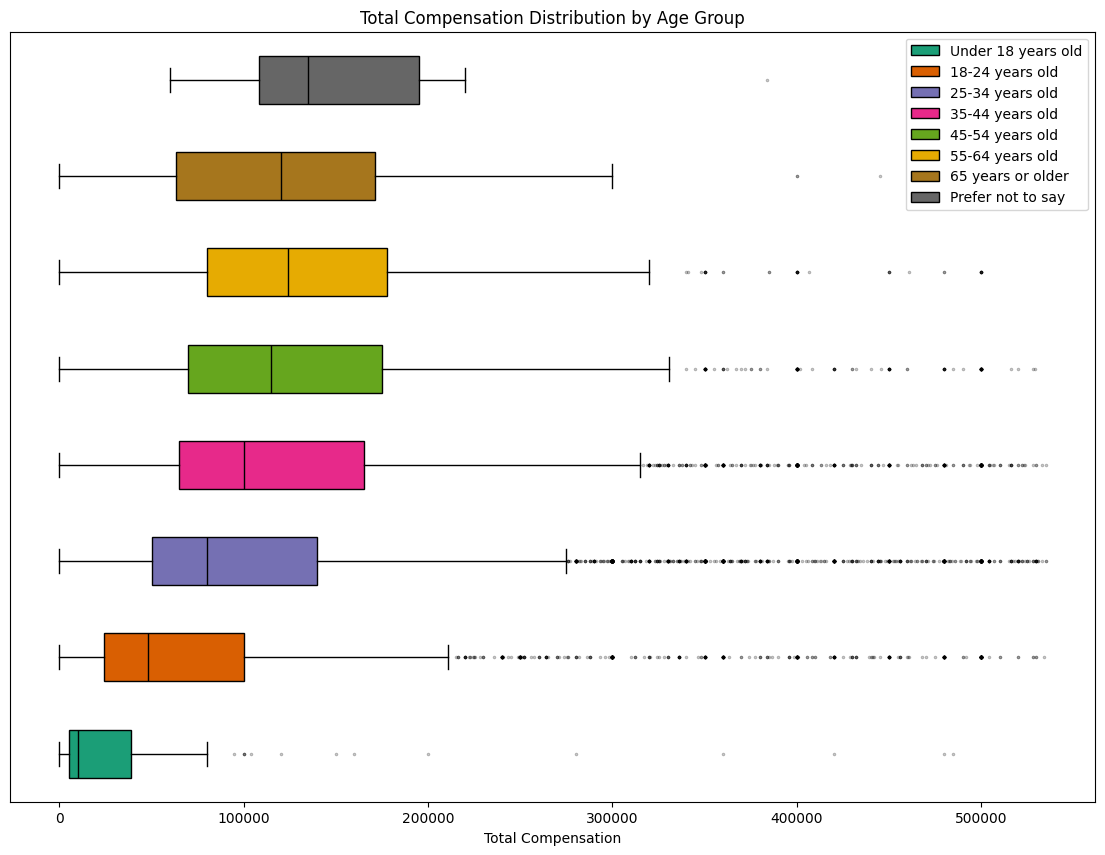

In [80]:
# your code goes here
plt.figure(figsize=(14,10))
bxplot=plt.boxplot([df_cleaned[df_cleaned["Age"]==age_grp]["CompTotal"] for age_grp in list(age_map.keys())],
            orientation='horizontal',
            patch_artist=True)
colors=plt.cm.Dark2(range(len(age_map)))
for box,color in zip(bxplot["boxes"],colors):
    box.set(facecolor=color)
for median in bxplot["medians"]:
    median.set(color='black')
for flier in bxplot["fliers"]:
    flier.set(marker='.', color='pink', alpha=0.3,markersize=3)
plt.title("Total Compensation Distribution by Age Group")
plt.xlabel("Total Compensation")
plt.legend(list(age_map.keys()))
plt.yticks([])
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


C:\Users\21650\AppData\Local\Temp\ipykernel_6100\2047061518.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["JobSat"]=df_cleaned["JobSat"].astype("Int64")


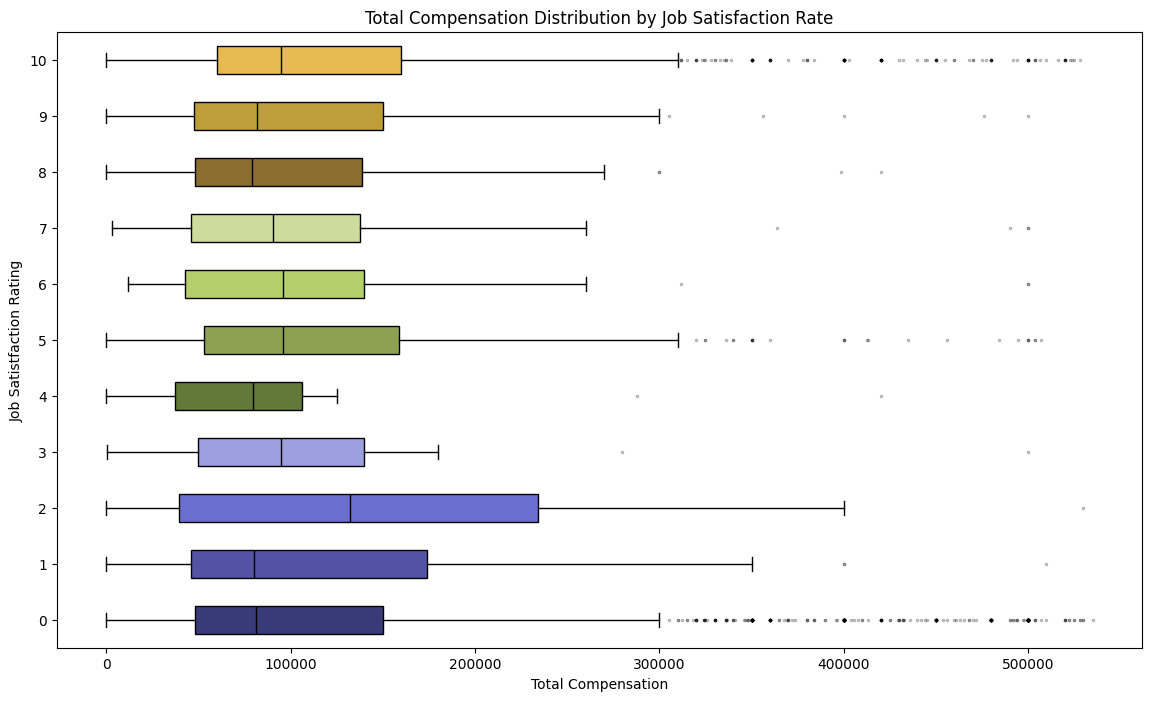

In [ ]:
# your code goes here
fig,ax=plt.subplots(figsize=(14,8))
bxplot=ax.boxplot([df_cleaned[df_cleaned["JobSatPoints_6"]==i]["CompTotal"] for i in range(0,11)],orientation="horizontal",patch_artist=True)
colors=plt.cm.tab20b.colors
for box,color in zip(bxplot["boxes"],colors):
    box.set(facecolor=color)
for median in bxplot["medians"]:
    median.set(color="black")
for flier in bxplot["fliers"]:
    flier.set(marker='.', color='pink', alpha=0.3,markersize=3)
ax.set_yticklabels(range(0,11))
ax.set_xlabel("Total Compensation")
ax.set_ylabel("Job Satistfaction Rating")
ax.set_title("Total Compensation Distribution by Job Satisfaction Rate")
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


C:\Users\21650\AppData\Local\Temp\ipykernel_6100\2470626991.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bxplot=ax.boxplot([df_filt[(df_filt["DevType"]==devtype)&(df_filt["ConvertedCompYearly"]<=ub)]["ConvertedCompYearly"] for devtype in top_dev],


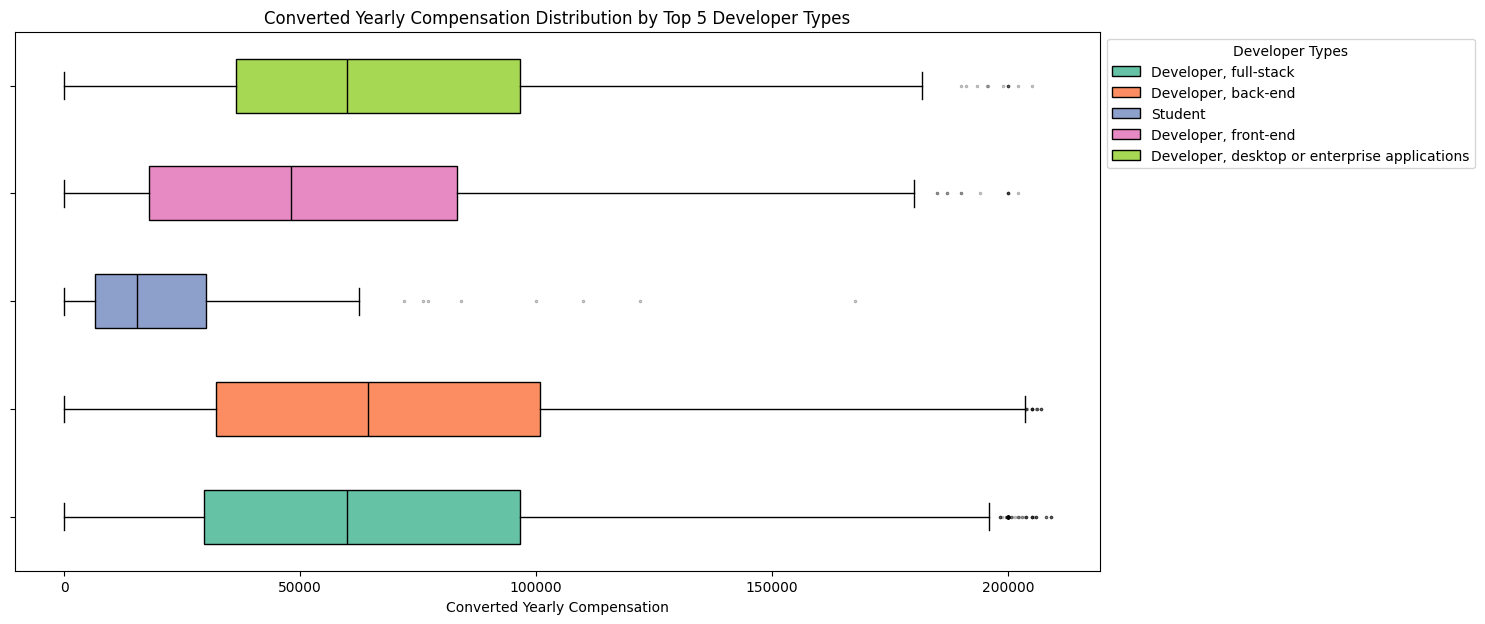

In [79]:
# your code goes here
df_filt=df.dropna(subset="DevType",axis=0).reset_index(drop=True)
# top_dev=df_filt[df_filt["DevType"].str.lower().str.contains("developer")]["DevType"].value_counts()[:5].index.tolist()
# df_filt=df_filt[df_filt["DevType"].isin(top_dev)]
top_dev=df_filt["DevType"].value_counts()[:5].index.tolist()
df_filt=df_filt[df_filt["DevType"].isin(top_dev)]
df_filt=df_filt.dropna(subset="ConvertedCompYearly",axis=0)
Q1=df_filt["ConvertedCompYearly"].quantile(.25)
Q3=df_filt["ConvertedCompYearly"].quantile(.75)
IQR=Q3-Q1
ub=Q3+1.5*IQR
fig,ax=plt.subplots(figsize=(14,7))
bxplot=ax.boxplot([df_filt[(df_filt["DevType"]==devtype)&(df_filt["ConvertedCompYearly"]<=ub)]["ConvertedCompYearly"] for devtype in top_dev],
                  labels=top_dev,
                  orientation='horizontal',
                  patch_artist=True)
colors=plt.cm.Set2(range(len(top_dev)))
for box,color in zip(bxplot["boxes"],colors):
    box.set(facecolor=color)
for median in bxplot["medians"]:
    median.set(color="black")
for flier in bxplot["fliers"]:
    flier.set(marker='.', color='pink', alpha=0.3,markersize=3)
ax.set_yticklabels([])
ax.legend(top_dev,title="Developer Types",bbox_to_anchor=[1,1])
ax.set_xlabel("Converted Yearly Compensation")
ax.set_title("Converted Yearly Compensation Distribution by Top 5 Developer Types")
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


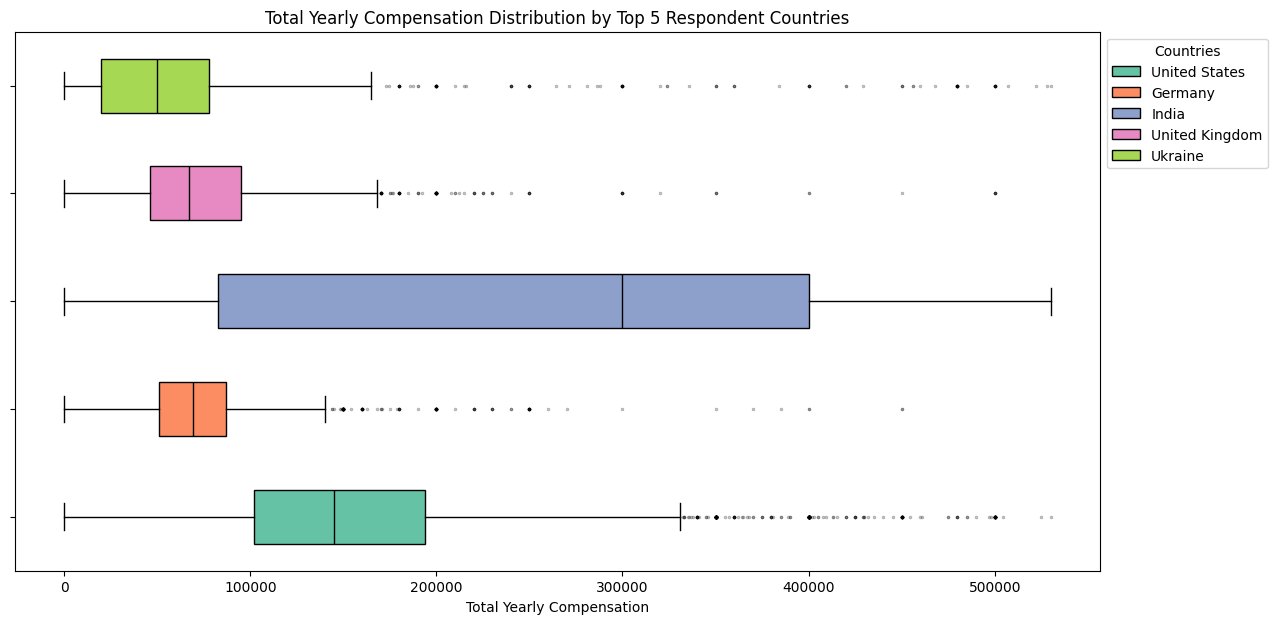

In [78]:
# your code goes here
top_countries=df["Country"].value_counts().index[:5].tolist()
fig,ax=plt.subplots(figsize=(14,7))
df_cleaned2=df_cleaned[df_cleaned["Country"].isin(top_countries)]
bxplot=ax.boxplot([df_cleaned2[df_cleaned2["Country"]==country]["CompTotal"] for country in top_countries],
                  orientation="horizontal",
                  patch_artist=True,)
colors=plt.cm.Set2(range(len(top_countries)))
for box,color in zip(bxplot["boxes"],colors):
    box.set(facecolor=color)
for median in bxplot["medians"]:
    median.set(color="black")
for flier in bxplot["fliers"]:
    flier.set(marker='.', color='pink', alpha=0.3,markersize=3)
top_countries[0]='United States'
top_countries[3]='United Kingdom'
ax.legend(top_countries,title="Countries",bbox_to_anchor=[1,1])
ax.set_yticklabels([])
ax.set_xlabel("Total Yearly Compensation")
ax.set_title("Total Yearly Compensation Distribution by Top 5 Respondent Countries")
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


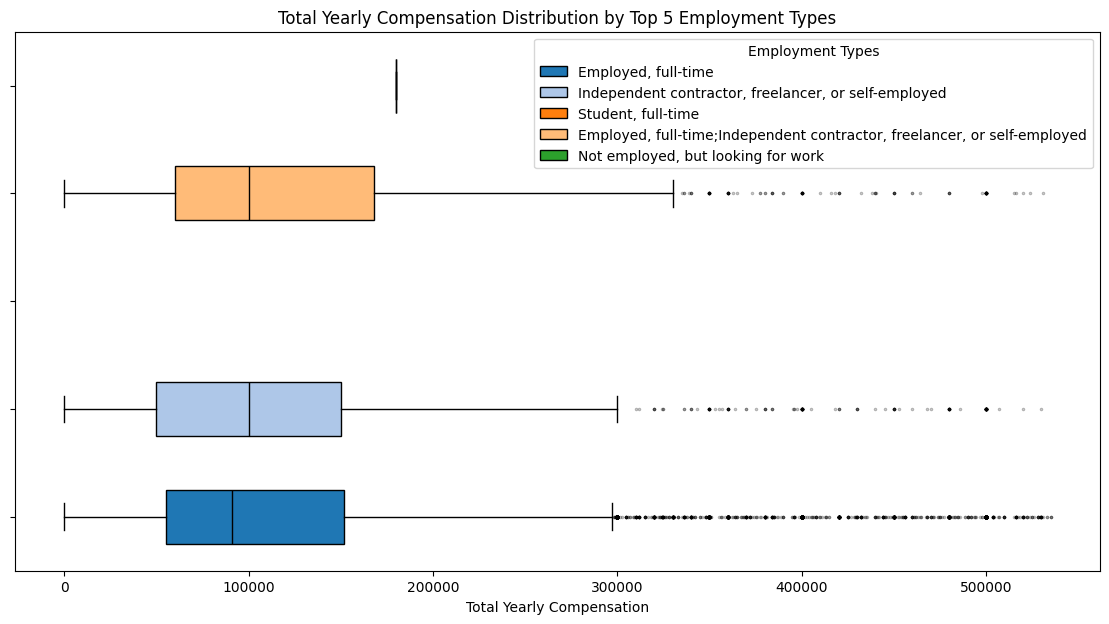

In [77]:
# your code goes here
top_empl=df["Employment"].value_counts().head().index.tolist()
fig,ax=plt.subplots(figsize=(14,7))
bxplot=ax.boxplot([df_cleaned[df_cleaned["Employment"]==empl]["CompTotal"] for empl in top_empl],
           orientation="horizontal",
           patch_artist=True)
colors=plt.cm.tab20(range(len(top_empl)))
for box,color in zip(bxplot["boxes"],colors):
    box.set(facecolor=color)
for median in bxplot["medians"]:
    median.set(color="black")
for flier in bxplot["fliers"]:
    flier.set(marker='.', color='pink', alpha=0.3,markersize=3)
ax.legend(top_empl,title="Employment Types",bbox_to_anchor=[1,1])
ax.set_yticklabels([])
ax.set_xlabel("Total Yearly Compensation")
ax.set_title("Total Yearly Compensation Distribution by Top 5 Employment Types")
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


C:\Users\21650\AppData\Local\Temp\ipykernel_6100\4009409346.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bxplot=ax.boxplot([df[df["JobSatPoints_6"]==i].dropna(subset='YearsCodePro',axis=0)["YearsCodePro"] for i in range(0,11)],


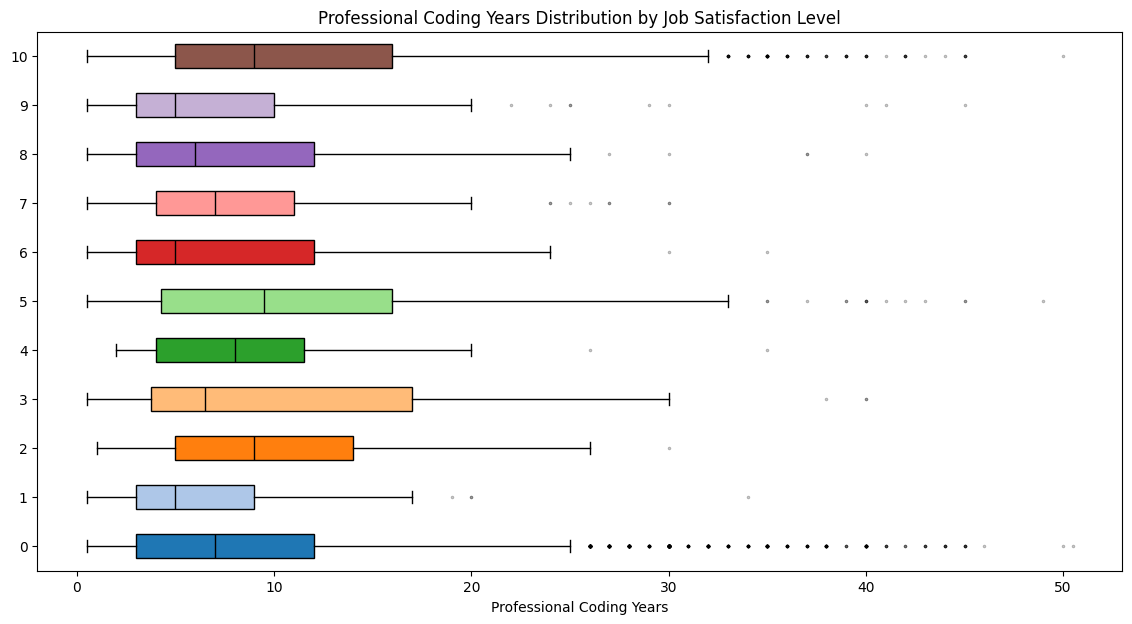

In [ ]:
# your code goes here
df["YearsCodePro"]=df["YearsCodePro"].replace({"Less than 1 year":.5,"More than 50 years":50.5,None:np.nan})
df["YearsCodePro"]=df["YearsCodePro"].astype("float")

fig,ax=plt.subplots(figsize=(14,7))
bxplot=ax.boxplot([df[df["JobSatPoints_6"]==i].dropna(subset='YearsCodePro',axis=0)["YearsCodePro"] for i in range(0,11)],
                  orientation="horizontal",
                  patch_artist=True,
                  labels=range(0,11))
colors=plt.cm.tab20(range(11))
for box,color in zip(bxplot["boxes"],colors):
    box.set(facecolor=color)
for median in bxplot["medians"]:
    median.set(color="black")
for flier in bxplot["fliers"]:
    flier.set(marker='.', color='pink', alpha=0.3,markersize=3)
ax.set_xlabel("Professional Coding Years")
ax.set_title("Professional Coding Years Distribution by Job Satisfaction Level")
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [16]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
